# Customer Segmentation Analysis

## OASIS INFOBYTE Data Analytics Internship

### Level 1 - Task 2

## Objective

The objective of this project is to segment e-commerce customers
based on their purchasing behaviour using RFM analysis and K-Means
clustering.

## Tools Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Jupyter Notebook

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
print("Shape:", df.shape)

Shape: (0, 32309)


In [ ]:
df.columns.tolist()

['{"cells":[{"cell_type":"markdown"',
 'id:"7c9b8473"',
 'metadata:{"papermill":{"duration":0.056654',
 'end_time:"2023-09-13T18:55:29.073469"',
 'exception:false',
 'start_time:"2023-09-13T18:55:29.016815"',
 'status:"completed"}',
 'tags:[]}',
 'source:["<img src=\\"https://github.com/FarzadNekouee/Retail_Customer_Segmentation_Recommendation_System/blob/master/image.png?raw=true\\" width=\\"2400\\">"]}',
 '{"cell_type":"markdown"',
 'id:"ae7b7d8d"',
 'metadata:{"papermill":{"duration":0.054531',
 'end_time:"2023-09-13T18:55:29.18267"',
 'exception:false.1',
 'start_time:"2023-09-13T18:55:29.128139"',
 'status:"completed"}.1',
 'tags:[]}.1',
 'source:["<div style=\\"border-radius:10px; padding: 15px; background-color: #ffeacc; font-size:130%; text-align:left\\">\\n"',
 '\\n',
 '<h2 align=\\left\\"><font color=#ff6200>Problem:</font></h2>\\n"',
 '\\n.1',
 '\\n.2',
 "In this project, we delve deep into the thriving sector of __online retail__ by analyzing a __transactional dataset__ fro

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Columns: 32309 entries, {"cells":[{"cell_type":"markdown" to nbformat_minor:5}
dtypes: object(32309)
memory usage: 132.0+ bytes


In [ ]:
df.isnull().sum()

,0
"{""cells"":[{""cell_type"":""markdown""",0
"id:""7c9b8473""",0
"metadata:{""papermill"":{""duration"":0.056654",0
"end_time:""2023-09-13T18:55:29.073469""",0
exception:false,0
...,...
"language:""python"".2",0
"sourceType:""notebook""",0
isGpuEnabled:false}},0
nbformat:4,0


In [ ]:
df.head()

,"{""cells"":[{""cell_type"":""markdown""","id:""7c9b8473""","metadata:{""papermill"":{""duration"":0.056654","end_time:""2023-09-13T18:55:29.073469""",exception:false,"start_time:""2023-09-13T18:55:29.016815""","status:""completed""}",tags:[]},"source:[""<img src=\""https://github.com/FarzadNekouee/Retail_Customer_Segmentation_Recommendation_System/blob/master/image.png?raw=true\"" width=\""2400\"">""]}","{""cell_type"":""markdown""",...,"version:""2.4.0""}","kaggle:{""accelerator"":""none""","dataSources:[{""sourceType"":""datasetVersion""",sourceId:3404}],isInternetEnabled:true,"language:""python"".2","sourceType:""notebook""",isGpuEnabled:false}},nbformat:4,nbformat_minor:5}


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ersany/online-retail-dataset")

print("Path to dataset files:", path)

100%|██████████| 21.8M/21.8M [00:01<00:00, 13.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ersany/online-retail-dataset/versions/1


In [ ]:
import os

print(os.listdir(path))

['Online Retail.xlsx']


In [ ]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/root/.cache/kagglehub/datasets/ersany/online-retail-dataset/versions/1/Online Retail.xlsx


In [ ]:
df = pd.read_excel(f"{path}/Online Retail.xlsx")
print(f"Dataset loaded successfully with {len(df)} rows and {len(df.columns)} columns.")
display(df.head())

Dataset loaded successfully with 541909 rows and 8 columns.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.isnull().sum()

,0
"{""cells"":[{""cell_type"":""markdown""",0
"id:""7c9b8473""",0
"metadata:{""papermill"":{""duration"":0.056654",0
"end_time:""2023-09-13T18:55:29.073469""",0
exception:false,0
...,...
"language:""python"".2",0
"sourceType:""notebook""",0
isGpuEnabled:false}},0
nbformat:4,0


In [ ]:
df = df.dropna(subset=["CustomerID"])

print("Rows after removing missing CustomerID:", len(df))

Rows after removing missing CustomerID: 406829


In [ ]:
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

print("Rows after cleaning:", len(df))

Rows after cleaning: 397884


In [ ]:
print("Final shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Final shape: (397884, 8)

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [ ]:
print("Final shape:", df.shape)
print(df.isnull().sum())

Final shape: (397884, 8)
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [ ]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df[["Quantity", "UnitPrice", "TotalAmount"]].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [ ]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Analysis Date:", analysis_date)

Analysis Date: 2011-12-10 12:50:00


In [ ]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (analysis_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [ ]:
rfm.describe()



,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [ ]:
rfm["AveragePurchaseValue"] = rfm["Monetary"] / rfm["Frequency"]

rfm[["Frequency", "Monetary", "AveragePurchaseValue"]].head()

,Frequency,Monetary,AveragePurchaseValue
CustomerID,,,
12346.0,1,77183.60,77183.600000
12347.0,7,4310.00,615.714286
12348.0,4,1797.24,449.310000
12349.0,1,1757.55,1757.550000
12350.0,1,334.40,334.400000


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary,AveragePurchaseValue
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460,419.166289
std,100.014169,7.697998,8989.230441,1796.537944
min,1.000000,1.000000,3.750000,3.450000
25%,18.000000,1.000000,307.415000,178.625000
50%,51.000000,2.000000,674.485000,293.900000
75%,142.000000,5.000000,1661.740000,430.113750
max,374.000000,209.000000,280206.020000,84236.250000


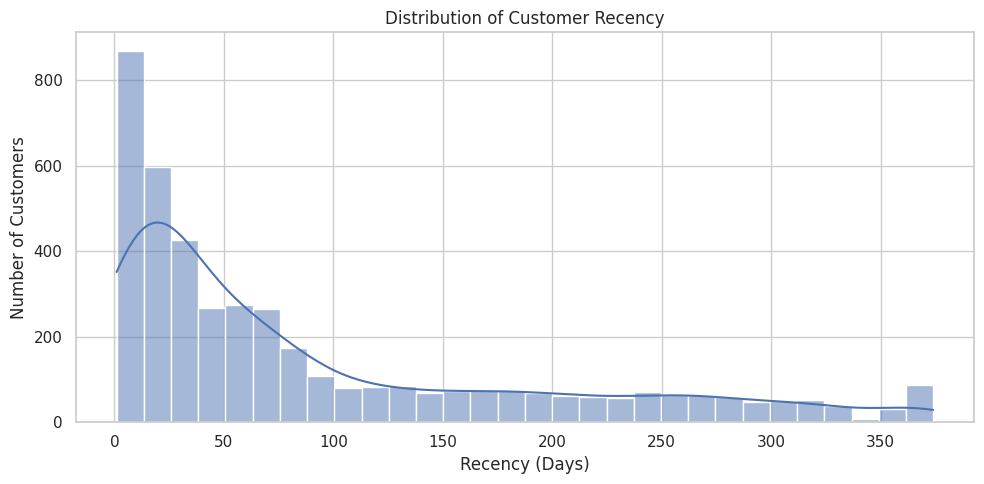

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(rfm["Recency"], bins=30, kde=True)

plt.title("Distribution of Customer Recency")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

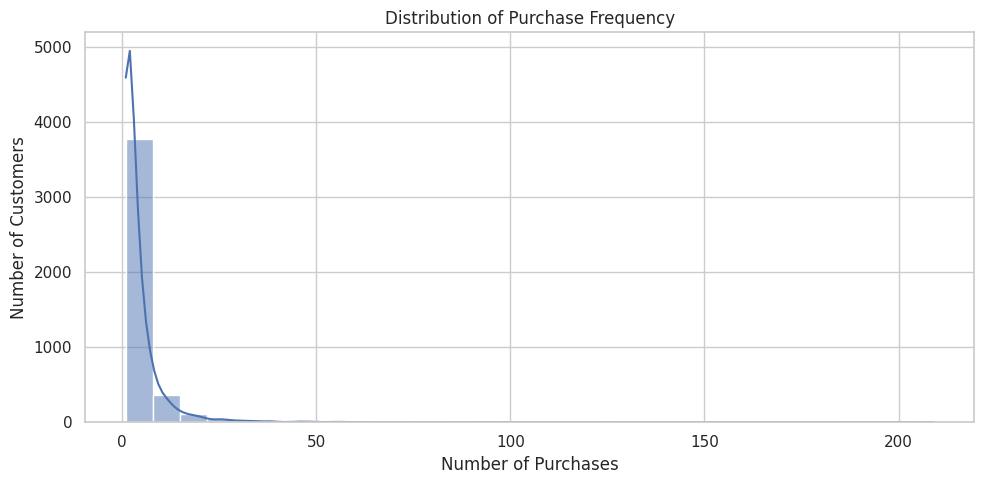

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(rfm["Frequency"], bins=30, kde=True)

plt.title("Distribution of Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

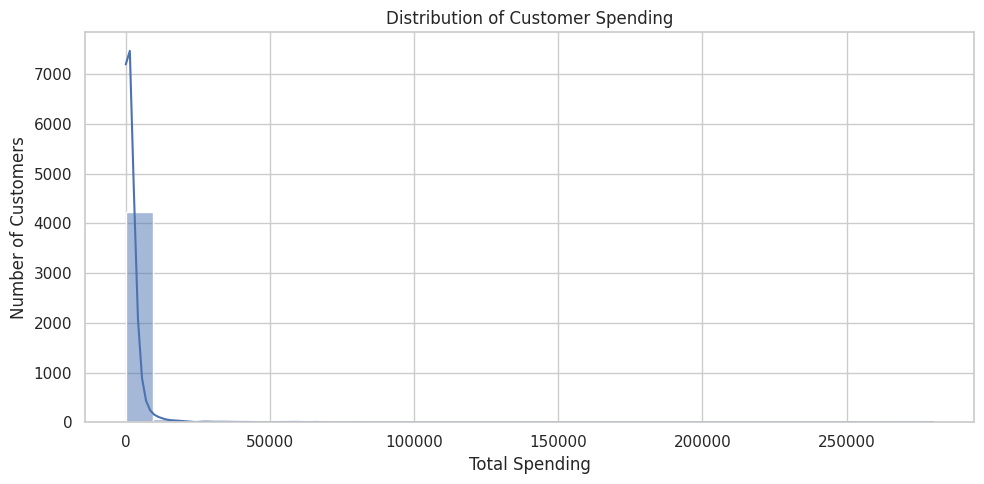

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(rfm["Monetary"], bins=30, kde=True)

plt.title("Distribution of Customer Spending")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [ ]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

for k, value in zip(range(2, 11), inertia):
    print(f"K = {k} → Inertia = {value:.2f}")

K = 2 → Inertia = 13982.56
K = 3 → Inertia = 9361.10
K = 4 → Inertia = 5587.89
K = 5 → Inertia = 4405.56
K = 6 → Inertia = 3343.96
K = 7 → Inertia = 2689.66
K = 8 → Inertia = 2335.07
K = 9 → Inertia = 2005.14
K = 10 → Inertia = 1757.07


In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,AveragePurchaseValue,Cluster
CustomerID,,,,,
12346.0,326,1,77183.60,77183.600000,1
12347.0,2,7,4310.00,615.714286,0
12348.0,75,4,1797.24,449.310000,0
12349.0,19,1,1757.55,1757.550000,0
12350.0,310,1,334.40,334.400000,2


In [ ]:
y_rf = rf.predict(X_test)
p_rf = rf.predict_proba(X_test)[:, 1]

print("Precision:", precision_score(y_test, y_rf))
print("Recall:", recall_score(y_test, y_rf))
print("F1:", f1_score(y_test, y_rf))
print("AUC:", roc_auc_score(y_test, p_rf))

NameError: name 'rf' is not defined